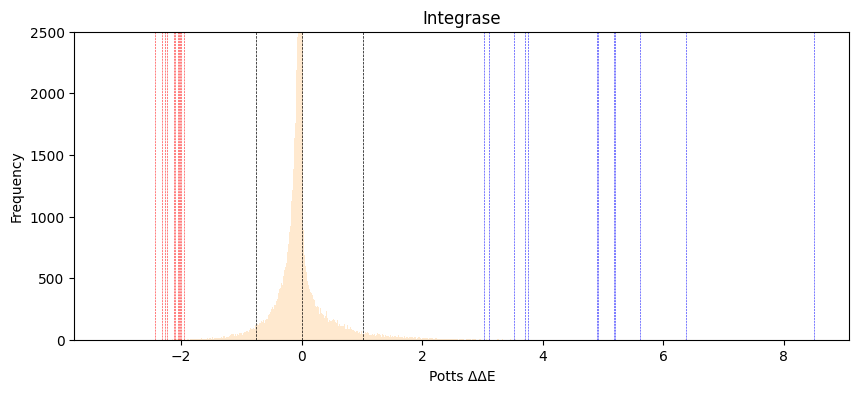

In [72]:
# Initialize dictionaries to store delta E and delta delta E values
import collections
import re


delta_e_per_position = collections.defaultdict(lambda: [0.0, 0.0, 0.0, 0.0])
delta_delta_e_per_pair = []

# Define mutation_map to map amino acids to indices
mutation_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

# Read the file and process the data
with open('data/kn.her2.all') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        columns = re.split(r'[,\t\s]+', line)
        mutations = columns[0]
        ddE = float(columns[1])
        delta_e1 = float(columns[3])
        delta_e2 = float(columns[4])
        
        # Extract positions from the mutation string
        positions = [int(pos) for pos in re.findall(r'\d+', mutations)]
        if len(positions) != 2:
            continue
        
        pos1, pos2 = positions
        
        #detect the wildtype 'first' aa seuqnce, and put A' delta e into [0]....D's delta e into [3]
        # Store delta E values for each position
        # Detect the wildtype 'first' amino acid sequence
        wildtype_aa1 = mutations[0]  # Extract the first amino acid from the mutation string
        wildtype_aa2 = mutations.split('-')[1][0]  # Extract the first letter after '-'
        mutate_aa1 = mutations[mutations.index('-') - 1]  # Extract the one letter before '-'
        mutate_aa2 = mutations[-1]
        # print(f"Processing mutation: {mutations}, Positions: {pos1}, {pos2}, Wildtype AAs: {wildtype_aa1}, {wildtype_aa2}, Mutated AA1: {mutate_aa1}, Mutated AA2: {mutate_aa2}")
        # Map the wildtype amino acid to the corresponding index in the delta_e_per_position list
        if mutate_aa1 in mutation_map:
            delta_e_per_position[pos1][mutation_map[mutate_aa1]] = delta_e1
        if mutate_aa2 in mutation_map:
            delta_e_per_position[pos2][mutation_map[mutate_aa2]] = delta_e2
        
        # Store delta delta E values for each pair of positions
        delta_delta_e_per_pair.append((pos1, pos2, ddE))

        # Print out the content in delta_delta_e_per_pair

import matplotlib.pyplot as plt
import numpy as np

# Extract ddE values from delta_delta_e_per_pair
ddE_values = [pair[2] for pair in delta_delta_e_per_pair]

# Create a figure with the desired size
plt.figure(figsize=(10,4))

# Plot the histogram
plt.hist(ddE_values, bins=1000, color='#ffe9cf')
plt.xlabel('Potts ΔΔE')
plt.ylabel('Frequency')
plt.title('Integrase')
plt.ylim(0, 2500)

# Calculate the 5th and 95th percentiles
percentile_neg = np.percentile(ddE_values, 1)
mean_ddE = np.mean(ddE_values)
percentile_pos = np.percentile(ddE_values, 99)

# Add black dashed lines for the percentiles
plt.axvline(percentile_neg, color='black', linestyle='--', linewidth=0.5, label='5th Percentile')
plt.axvline(percentile_pos, color='black', linestyle='--', linewidth=0.5, label='95th Percentile')

# Add a red dashed line for the mean
plt.axvline(mean_ddE, color='black', linestyle='--', linewidth=0.5, label='Mean')


# Sort delta_delta_e_per_pair by ddE values
delta_delta_e_per_pair_sorted = sorted(delta_delta_e_per_pair, key=lambda x: x[2])
drug_resistant_positions = [66, 92, 118, 138, 140, 143, 147, 148, 155, 263]

# Filter synergistic and antagonistic drug-resistant pairs
synergistic_drug_resistant_pairs = [
    pair for pair in delta_delta_e_per_pair_sorted
    # if (pair[0], pair[1]) in [
    #     (140, 148), (143, 230), (140, 148), (140, 148), (140, 148), (140, 148), (138, 148),
    #     (140, 148), (138, 148), (143, 230), (155, 170), (138, 147), (147, 148), (143, 151),
    #     (138, 148), (147, 158), (92, 215), (138, 148), (138, 230), (138, 194)
    # ]
    if pair[0] in drug_resistant_positions or pair[1] in drug_resistant_positions
]
antagonistic_drug_resistant_pairs = [
    pair for pair in delta_delta_e_per_pair_sorted
    # if (pair[0], pair[1]) in [
    #     (143, 155), (148, 155), (140, 155), (140, 147), (143, 148), (148, 155), (140, 143),
    #     (92, 143), (140, 147), (92, 148), (155, 193), (92, 140), (143, 148), (140, 230),
    #     (147, 151), (148, 165), (155, 176), (155, 160), (143, 234), (92, 163)
    # ]
    if pair[0] in drug_resistant_positions or pair[1] in drug_resistant_positions
]

# Calculate the top negative and positive percentiles
percentile_top_neg = np.percentile(ddE_values, 0.02)  # Adjust the percentile as needed
percentile_top_pos = np.percentile(ddE_values, 99.98)  # Adjust the percentile as needed

# Extract ddE values for top negative and positive pairs
# Filter top negative values based on synergistic drug-resistant pairs
# Filter top negative values based on antagonistic drug-resistant pairs
top_neg_values = [
    pair[2] for pair in antagonistic_drug_resistant_pairs
    if pair[2] <= percentile_top_neg
]

# Filter top positive values based on synergistic drug-resistant pairs
top_pos_values = [
    pair[2] for pair in synergistic_drug_resistant_pairs
    if pair[2] >= percentile_top_pos
]

# Add red dashed lines for all top negative values with transparency
for value in top_neg_values:
    plt.axvline(value, color='#ff1c1c', linestyle='--', linewidth=0.4, alpha=1)

# Add green dashed lines for all top positive values with transparency
for value in top_pos_values:
    plt.axvline(value, color='#1818ff', linestyle='--', linewidth=0.4, alpha=1)



# Add legend
# plt.legend()

plt.show()



